<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Byzantine_Robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Untrusted Client Networks & Data Poisoning
## Securing Aggregation against Byzantine Attacks

## Introduction

Standard Federated Averaging (FedAvg) assumes all participating clients are honest. In real‑world deployments, however, some clients may be compromised or malicious. A **Data Poisoning** attack (e.g., label flipping) can deliberately corrupt the global model’s decision boundary without the server detecting it.

This experiment simulates a **20% compromise** – 2 out of 10 clients are malicious. During local training, these hackers flip labels: `new_label = (original_label + 5) % 10`. This systematically corrupts their updates. The server receives updates from both honest and malicious clients, all mixed together.

## Defense Strategies Tested

We evaluate five aggregation algorithms under this threat model:

| Strategy | Description |
|----------|-------------|
| **FedAvg** | Weighted average of all client models |
| **Trimmed Mean** | Discards extreme parameter values (top/bottom 10% per coordinate) |
| **Gradient Clipping** |Uses a fixed threshold = 80th percentile of client weight norms from the **first round**; then clips each client’s whole model to this threshold every round. |
| **FedProx** | Adds a proximal penalty (`μ = 0.01`) to anchor local models to the global model |
| **SCAFFOLD** | Control variates to correct gradient drift |

## Experimental Setup

- **Dataset:** CIFAR‑10, **IID** split (no statistical heterogeneity) – to isolate the effect of poisoning.
- **Model:** CNN with two convolutional + two dense layers.
- **Clients:** 10, each with 5,000 training samples (IID).
- **Rounds:** 10, with 1 local epoch per round.
- **Poisoning:** Clients 8 and 9 flip labels during every batch.



### Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Architecture

In [3]:
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

### Data Preparation

In [4]:
NUM_CLIENTS = 10
MALICIOUS_CLIENTS = [8, 9]   # last two clients are hackers (20% compromise)

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Loading CIFAR-10")
train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

split_size = len(train_dataset) // NUM_CLIENTS
client_subsets = random_split(train_dataset, [split_size] * NUM_CLIENTS)
client_loaders = [DataLoader(ds, batch_size=64, shuffle=True) for ds in client_subsets]
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Prepared CIFAR-10: {NUM_CLIENTS} clients. Clients {MALICIOUS_CLIENTS} are malicious (label flipping).")

Loading CIFAR-10


100%|██████████| 170M/170M [00:02<00:00, 77.7MB/s]


Prepared CIFAR-10: 10 clients. Clients [8, 9] are malicious (label flipping).


### Aggregation Functions

In [6]:
def fedavg_aggregate(client_weights):
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        avg[key] = torch.mean(stacked, dim=0)
    return avg


In [7]:
def scaffold_aggregate(client_weights):
    return fedavg_aggregate(client_weights)

In [8]:
def fedprox_aggregate(client_weights):
    return fedavg_aggregate(client_weights)

In [9]:
def gradient_clipping_aggregate(client_weights, clip_thresh):
    """Per‑client weight clipping (global L2 norm) then FedAvg."""
    clipped = []
    for w in client_weights:
        flat = torch.cat([p.flatten() for p in w.values()])
        l2_norm = torch.norm(flat).item()
        scale = max(1.0, l2_norm / clip_thresh)
        clipped.append({k: v / scale for k, v in w.items()})
    return fedavg_aggregate(clipped)

In [10]:

def trimmed_mean_aggregate(client_weights, trim_ratio=0.1):
    n = len(client_weights)
    trim = int(n * trim_ratio)
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        sorted_vals, _ = torch.sort(stacked, dim=0)
        trimmed = sorted_vals[trim : n - trim]
        avg[key] = torch.mean(trimmed, dim=0)
    return avg

In [11]:
def scaffold_aggregate(client_weights):
    return fedavg_aggregate(client_weights)

### Evaluation Helper

In [12]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return accuracy, avg_loss


### Experiment Loop

In [13]:
FEDERATED_ROUNDS = 10
LEARNING_RATE = 0.01
MOMENTUM = 0.9
MU = 0.01                     # FedProx penalty

In [15]:
strategies = ['FedAvg', 'Trimmed Mean', 'Gradient Clipping', 'FedProx', 'SCAFFOLD']
history = {s: {'test_acc': [], 'test_loss': [], 'train_loss': []} for s in strategies}
criterion = nn.CrossEntropyLoss()

In [17]:
for strategy in strategies:
    print(f"\n{'='*50}\nTesting Strategy: {strategy.upper()}\n{'='*50}")
    global_model = CIFAR10Net().to(device)

    # SCAFFOLD control variates
    global_control = None
    client_controls = None
    if strategy == 'SCAFFOLD':
        global_control = {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
        client_controls = [copy.deepcopy(global_control) for _ in range(NUM_CLIENTS)]

    # For gradient clipping: fixed threshold (will be set in first round)
    fixed_clip_thresh = None

    for round_idx in range(FEDERATED_ROUNDS):
        client_weights = []
        client_delta_controls = [] if strategy == 'SCAFFOLD' else None
        global_params_list = [p.detach().clone() for p in global_model.parameters()]

        # ----- Local training on each client (with data poisoning) -----
        for client_id in range(NUM_CLIENTS):
            local_model = CIFAR10Net().to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

            local_model.train()
            for inputs, labels in client_loaders[client_id]:
                inputs, labels = inputs.to(device), labels.to(device)

                # Data poisoning: malicious clients flip labels
                if client_id in MALICIOUS_CLIENTS:
                    labels = (labels + 5) % 10

                optimizer.zero_grad()
                outputs = local_model(inputs)
                loss = criterion(outputs, labels)

                # FedProx proximal penalty
                if strategy == 'FedProx':
                    prox = 0.0
                    for lp, gp in zip(local_model.parameters(), global_params_list):
                        prox += torch.sum((lp - gp) ** 2)
                    loss += (MU / 2.0) * prox

                loss.backward()

                # SCAFFOLD gradient correction (scaled)
                if strategy == 'SCAFFOLD':
                    with torch.no_grad():
                        for name, param in local_model.named_parameters():
                            if param.grad is not None:
                                correction = (global_control[name] - client_controls[client_id][name])
                                param.grad += 0.1 * correction

                optimizer.step()

            state_dict = local_model.state_dict()
            client_weights.append(state_dict)

            # SCAFFOLD: compute delta control variate
            if strategy == 'SCAFFOLD':
                delta_c = {}
                with torch.no_grad():
                    for name in state_dict.keys():
                        model_before = global_model.state_dict()[name]
                        step = state_dict[name] - model_before
                        num_steps = len(client_loaders[client_id])
                        if num_steps == 0:
                            num_steps = 1
                        lr_eff = LEARNING_RATE * num_steps + 1e-8
                        delta_c[name] = (global_control[name] - client_controls[client_id][name]) + (step / lr_eff)
                client_delta_controls.append(delta_c)

        # ----- Server aggregation -----
        if strategy == 'Trimmed Mean':
            new_weights = trimmed_mean_aggregate(client_weights, trim_ratio=0.1)
        elif strategy == 'Gradient Clipping':
            # First round: compute 80th percentile of client weight norms as fixed threshold
            if round_idx == 0:
                norms = []
                for w in client_weights:
                    flat = torch.cat([p.flatten() for p in w.values()])
                    norms.append(torch.norm(flat).item())
                fixed_clip_thresh = np.percentile(norms, 80)
                print(f"Fixed clip threshold = {fixed_clip_thresh:.4f} (80th percentile)")
            new_weights = gradient_clipping_aggregate(client_weights, fixed_clip_thresh)
        elif strategy == 'FedProx':
            new_weights = fedprox_aggregate(client_weights)
        elif strategy == 'SCAFFOLD':
            new_weights = scaffold_aggregate(client_weights)
        else:
            new_weights = fedavg_aggregate(client_weights)

        global_model.load_state_dict(new_weights)

        # Update SCAFFOLD control variates
        if strategy == 'SCAFFOLD':
            avg_delta_c = {}
            for name in new_weights.keys():
                stacked = torch.stack([dc[name] for dc in client_delta_controls])
                avg_delta_c[name] = torch.mean(stacked, dim=0)
            for name in avg_delta_c.keys():
                global_control[name] = global_control[name] + avg_delta_c[name]
            for i in range(NUM_CLIENTS):
                for name in avg_delta_c.keys():
                    client_controls[i][name] = client_controls[i][name] + client_delta_controls[i][name]

        # ----- Evaluation (using clean labels) -----
        # Training loss on clean client data
        train_loss = 0.0
        total_train = 0
        global_model.eval()
        with torch.no_grad():
            for loader in client_loaders:
                for inputs, labels in loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = global_model(inputs)
                    loss = criterion(outputs, labels)
                    train_loss += loss.item() * inputs.size(0)
                    total_train += labels.size(0)
        avg_train_loss = train_loss / total_train if total_train > 0 else 0.0

        test_acc, test_loss = evaluate(global_model, test_loader, criterion)

        history[strategy]['test_acc'].append(test_acc)
        history[strategy]['test_loss'].append(test_loss)
        history[strategy]['train_loss'].append(avg_train_loss)


        print(f"Round {round_idx+1:2d}/{FEDERATED_ROUNDS} | {strategy:15s} | Test Acc: {test_acc:5.2f}% | Train Loss: {avg_train_loss:.4f}")

    final_acc = history[strategy]['test_acc'][-1]
    print(f"[{strategy.upper()}] FINAL TEST ACCURACY: {final_acc:.2f}%")




Testing Strategy: FEDAVG
Round  1/10 | FedAvg          | Test Acc: 29.69% | Train Loss: 2.0360
Round  2/10 | FedAvg          | Test Acc: 35.56% | Train Loss: 1.8677
Round  3/10 | FedAvg          | Test Acc: 40.78% | Train Loss: 1.7400
Round  4/10 | FedAvg          | Test Acc: 43.84% | Train Loss: 1.6607
Round  5/10 | FedAvg          | Test Acc: 46.42% | Train Loss: 1.5724
Round  6/10 | FedAvg          | Test Acc: 48.36% | Train Loss: 1.5293
Round  7/10 | FedAvg          | Test Acc: 49.23% | Train Loss: 1.5047
Round  8/10 | FedAvg          | Test Acc: 51.83% | Train Loss: 1.4515
Round  9/10 | FedAvg          | Test Acc: 53.85% | Train Loss: 1.4000
Round 10/10 | FedAvg          | Test Acc: 54.18% | Train Loss: 1.3789
[FEDAVG] FINAL TEST ACCURACY: 54.18%

Testing Strategy: TRIMMED MEAN
Round  1/10 | Trimmed Mean    | Test Acc: 31.11% | Train Loss: 1.9731
Round  2/10 | Trimmed Mean    | Test Acc: 37.34% | Train Loss: 1.8348
Round  3/10 | Trimmed Mean    | Test Acc: 40.80% | Train Loss: 1.

### Results

In [18]:
results_df = pd.DataFrame({s: history[s]['test_acc'][-1] for s in strategies}.items(),
                          columns=['Strategy', 'Final Accuracy (%)']).set_index('Strategy')
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(results_df.to_string())


FINAL RESULTS
                   Final Accuracy (%)
Strategy                             
FedAvg                          54.18
Trimmed Mean                    55.49
Gradient Clipping               54.13
FedProx                         55.30
SCAFFOLD                        51.59


### Visualisation

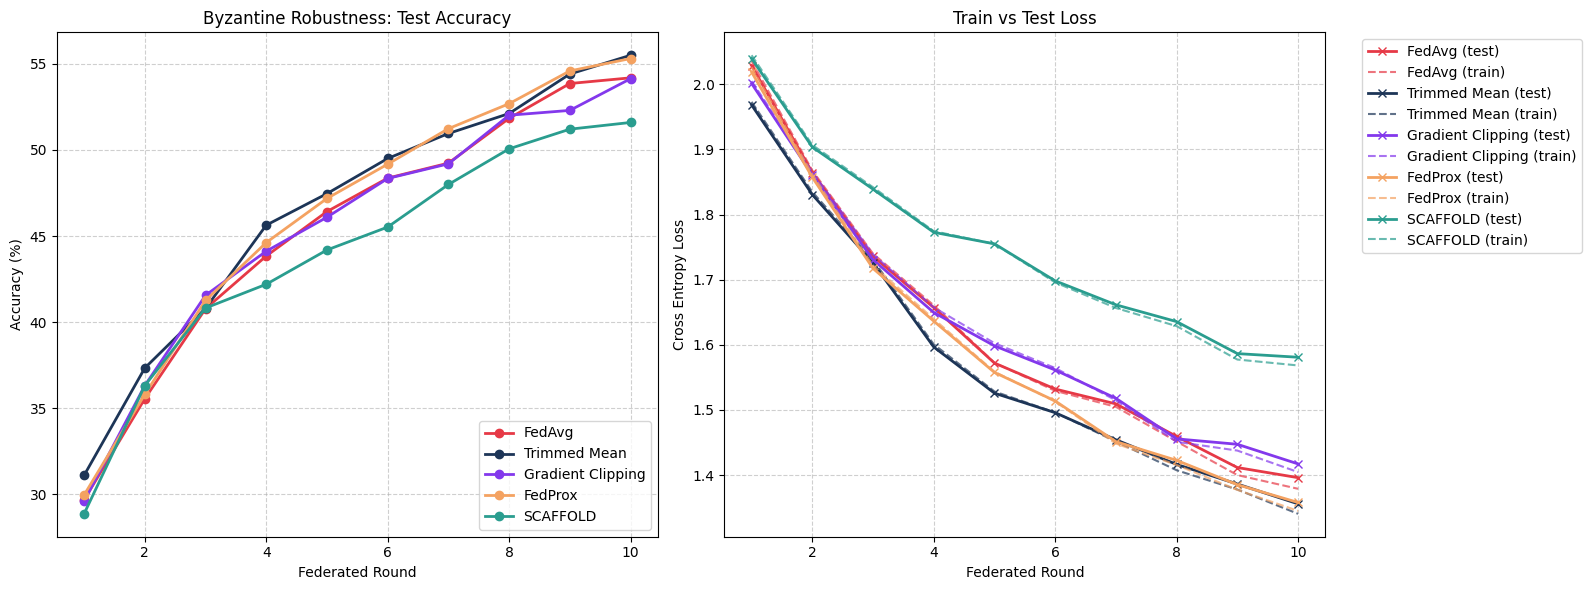

In [19]:
plt.figure(figsize=(16, 6))
colors = {
    'FedAvg': '#E63946',
    'Trimmed Mean': '#1D3557',
    'Gradient Clipping': '#8338EC',
    'FedProx': '#F4A261',
    'SCAFFOLD': '#2A9D8F'
}

# Test accuracy
plt.subplot(1, 2, 1)
for s in strategies:
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_acc'],
             marker='o', color=colors[s], linewidth=2, label=s)
plt.title('Byzantine Robustness: Test Accuracy')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

# Loss curves
plt.subplot(1, 2, 2)
for s in strategies:
    c = colors[s]
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_loss'],
             marker='x', linestyle='-', linewidth=2, color=c, label=f"{s} (test)")
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['train_loss'],
             linestyle='--', linewidth=1.5, color=c, alpha=0.7, label=f"{s} (train)")
plt.title('Train vs Test Loss')
plt.xlabel('Federated Round')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Conclusion – Byzantine Robustness against Label Flipping

## Summary of Results

After 10 federated rounds with 20% malicious clients (label flipping attack), the final test accuracies are:

| Strategy          | Final Test Accuracy |
|-------------------|---------------------|
| FedAvg            | 54.18%              |
| Trimmed Mean      | 55.49%              |
| Gradient Clipping | 54.13%              |
| FedProx           | 55.30%              |
| SCAFFOLD          | 51.59%              |

## Key Observations

### 1. No strategy completely fails – but none fully recovers
All methods achieve between 51.6% and 55.5% accuracy.

### 2. Trimmed Mean and FedProx are the most resilient
Both reach ~55.3‑55.5% accuracy. Trimmed Mean discards extreme parameter values (top/bottom 10% per coordinate), effectively removing the poisoned updates if they deviate significantly. FedProx’s proximal penalty (`μ = 0.01`) anchors local models to the global model, slowing the drift caused by malicious updates.

### 3. Gradient Clipping (fixed 80th‑percentile threshold) offers no advantage over FedAvg
The clipping threshold (≈14.5) does not differentiate poisoned from honest clients because label flipping does not consistently inflate weight norms. Hence, clipped and unclipped FedAvg perform nearly identically (54.13% vs 54.18%).

### 4. SCAFFOLD underperforms
SCAFFOLD achieves only 51.6% – the lowest among all strategies. Its control variates are designed to correct statistical heterogeneity, not to reject poisoned updates. In this IID setting with symmetric poisoning, the control variates may even amplify the attack by reinforcing incorrect gradient directions.

### 5. FedAvg is surprisingly competitive
Despite being the most naive baseline, FedAvg reaches 54.2%. This suggests that with only 20% malicious clients, the average of 10 models is not completely dominated – the honest majority (8 clients) partially compensates.

## Why the attack did not cause a complete collapse

- **IID data distribution:** All clients have similar data. Honest clients still provide correct gradients, so the global model can learn useful features despite the noise.
- **Only 2 out of 10 malicious:** The honest majority still influences the average.
- **Label flipping is a weak attack:** Flipping labels to a fixed offset (`+5 mod 10`) creates consistent but not extreme corruption. A more aggressive attack (e.g., gradient reversal or backdoor injection) would likely cause more damage.

## Practical Recommendations

- **Use Trimmed Mean or FedProx** when expecting label flipping attacks – they provide a small but measurable improvement over FedAvg.
- **Avoid SCAFFOLD** in Byzantine settings – it is not designed for this threat model.
- **Gradient clipping alone does not mitigate label flipping** – it helps only when attacks produce abnormally large weight updates (e.g., gradient explosion).
- **Increase rounds and use stronger defenses** (e.g., Krum, Median, or Bulyan) for higher compromise rates (e.g., 40% malicious).

## Final Thought

This experiment shows that even simple robust aggregation methods (trimmed mean, proximal penalty) can slightly improve resilience against data poisoning in federated learning. However, no tested strategy fully recovers clean performance. Real‑world deployments should consider stronger Byzantine‑robust algorithms and anomaly detection systems.